# KFold
- 데이터셋을 K개의 동일 크기 부분(Fold)으로 나눠서 K번 반복하여 하나의 폴드를 검증용으로 사용하고 나머지 K-1개의 폴드를 학습용으로 사용
- 모든 폴드를 한 번은 검증용으로 포함되고 K-1개를 학습용으로 사용
- 데이터의 수가 적을 때 모델의 성능을 안정적으로 평가할 수 있는 방법

- **장점**
    - 데이터를 폴드화해 학습/검증용으로 사용하기 때문에 데이터를 낭비하지 않는다.
    - 일반적으로 사용하던 train_test_split보다 성능 평가가 안정적(설명이 충분)이다.

- **단점**
    - K번의 학습 → K번의 예측 → K번의 평가 → 계산이 늘어남 → 시간 증가
    - 데이터의 크기가 크면 시간 증가

- **변형 KFold 클래스**
    -  StratifiedKFold
    </br>: 분류 문제에서 클래스의 비율을 유지하여 분할
    - GroupKFold
    </br>: 그룹 단위로 데이터를 나눠 그룹이 학습/검증에 동시에 들어가지 않도록 보장
    - RepeatedKFold
    </br>: KFold를 여러 번 반복해 평가 안정성 강화 (거의 안 씀)

- **매개변수**
    - <span style="color:#ffd33d">**n_splits**</span>
        </br>: 폴드의 개수를 지정
        - 기본값: 5
            - 최솟값은 2
    - <span style="color:#ffd33d">**shuffle**</span>
        </br>: 데이터를 분할하기 전에 섞을 것인가?
        - 기본값: False
            - True : 폴드 랜덤 구성
    - <span style="color:#ffd33d">**random_state**</span>
        </r>: 랜덤 시드 고정
        - shuffle이 True인 경우에 사용
        - 기본값: None
    
- **속성** (중요X)
    - <span style="color:#ffd33d">**n_splits**</span>
        </br>: 분할된 폴드의 개수

- **메소드** (중요)
    - <span style="color:#ffd33d">**split(x, y=None)**</span>
        </br>: 학습/검증용 인덱스 생성
        - 반복문을 이용해 (train_index, test_index)로 변환하여 사용
        - y의 기본값은 None

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, StratifiedKFold
    # 분류에서는 계층화된 KFold (StratifiedKFold),  회귀에서는 KFold 사용
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.metrics import classification_report, r2_score

In [3]:
# Pipeline + GridSearchCV + KFold를 사용하여 분류 문제 해결

# iris 데이터 로드
iris = pd.read_csv('../data/iris.csv')
iris.head()

,sepal length,sepal width,petal length,petal width,target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
# target 데이터를 0, 1, 2로 변경
# iris['target'].unique()

for i, key in enumerate(iris['target'].unique()):
    # print(i)      # 위치 값들 하나씩 대입
    # print(key)    # 고유한 값들 하나씩 대입
    iris['target'] = iris['target'].replace(key, i)

iris['target'].value_counts()

C:\Users\johnh\AppData\Local\Temp\ipykernel_26648\279195980.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  iris['target'] = iris['target'].replace(key, i)


target
0    50
1    50
2    50
Name: count, dtype: int64

In [5]:
# train, test 데이터셋 구분
x = iris.drop('target', axis= 1).values
y = iris['target'].values

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size= 0.2, random_state= 42, stratify= y
)
# test_size를 0.2로 설정해 KFold를 5개로 나눔

In [7]:
# KFold를 이용해 데이터 분할
# 분류 모델 현재 target 데이터의 비율은 약 1:1:1
# -> 비율을 맞춰서 폴드화하기 위해 stratifiedKFold를 이용
cv_folds = StratifiedKFold(n_splits= 5, shuffle= True, random_state= 42)

In [8]:
cv_folds

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [9]:
# 파이프라인 생성
# 학습(fit()) -> Scaler 생성, fit()을 이용해 범위 지정, transform()을 이용해 스케일링하고, 모델에 학습시킨다.
# 예측(predict()) -> 생성된 Scaler를 사용, transform()을 이용해 검증 데이터를 스케일링하고, 학습된 모델에 predict() 함수를 이용해 예측값을 반환한다.
pipe = Pipeline(
    [
        ('sclaer', StandardScaler()),
        ('svc', SVC(probability= True, random_state= 42))
    ]
)

In [10]:
# GridSearchCV에서 사용할 파라미터 조합 생성
# pipeline을 이용하여 Grid를 사용하려면, 매개변수의 이름을 수정할 필요가 있다.
    # (∵ pipeline에는 C, gamma, kernel이 존재하지 않는다.)
# pipeline에서 사용할 모델의 key값들을 변경 ( 모델명__매개변수명 )
params = {
    # "C": [0.1, 1, 10],
    "svc__C": [0.1, 1, 10],
    # "gamma" : ['scale', 'auto'], 
    "svc__gamma" : ['scale', 'auto'],
    # 'kernel' : ['linear', 'rbf']
    'svc__kernel' : ['linear', 'rbf']
}

In [11]:
grid_cls = GridSearchCV(
    estimator= pipe,            # grid에서 사용할 모델을 pipeline으로 만들어진 모델로 지정
    param_grid= params,         # dict 형태로 각 파라미터별 사용할 값 지정
    scoring= 'accuracy',        # 검증할 때마다 정확도를 이용하여 모델 평가
    cv= cv_folds,               # 교차 검증 횟수는 KFold의 값들을 이용
    verbose= 1,                 # 진행 상황을 간단한 로그로 표시 (높은 수일수록 자세히)
    refit= True,                # 베스트 파라미터를 이용해 재학습
    return_train_score= True,   # 학습 데이터의 성능 확인
    n_jobs= 1                   # 모든 코어를 사용해 작업
)

grid_cls.fit(X_train, Y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'svc__C': [0.1, 1, ...], 'svc__gamma': ['scale', 'auto'], 'svc__kernel': ['linear', 'rbf']}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


In [ ]:
# print(grid_cls.cv_results_)     # 딕셔너리 형태, value가 1차원 배열
# 보기 편하게 데이터프레임으로 출력
pd.DataFrame(grid_cls.cv_results_).sort_values(
    "mean_test_score", ascending= False
)

---

In [13]:
# pipe + kfold + grid를 이용한 회귀 분석
# csv에 있는 boston 데이터 로드
boston = pd.read_csv('../csv/boston.csv')
boston.head(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98,24.0


In [14]:
x = boston.drop('Price', axis= 1).values
y = boston['Price']

In [15]:
# train, test 분할
# 회귀분석이기 때문에 계층화 사용하지 않음
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size= 0.2, random_state= 42
)

In [16]:
# 폴드화에서도 계층화가 필요 없기때문에 KFold 사용
cv_folds = KFold(n_splits=5, shuffle = True, random_state=42)

pipe_reg = Pipeline(
    [
        ('stdscaler', StandardScaler()), 
        ('svm_reg', SVR())
    ]
)
# SVR() 모델의 파라미터를 C는 [1, 10, 100]
# kenrle은 ['rbf', 'linear]
# epsilon은 [0.1, 0.2, 0.5]
# 파라미터 조합 
params_reg = {
    "svm_reg__C" : [1, 10, 100], 
    "svm_reg__kernel" : ['rbf', 'linear'], 
    "svm_reg__epsilon" : [0.1, 0.2, 0.5]
}
# GridSearchCV를 이용하여 최적화 파라미터를 확인 
# scoring은 'neg_mean_squared_error'
grid_reg = GridSearchCV(
    estimator= pipe_reg, 
    param_grid= params_reg, 
    scoring='neg_mean_squared_error', 
    cv = cv_folds, 
    verbose= 1, 
    refit = True, 
    return_train_score=True
)
grid_reg.fit(X_train, Y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,estimator,"Pipeline(step...reg', SVR())])"
,param_grid,"{'svm_reg__C': [1, 10, ...], 'svm_reg__epsilon': [0.1, 0.2, ...], 'svm_reg__kernel': ['rbf', 'linear']}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,copy,True


# PCA (주성분 분석)
- 차원 축소 기법 중 하나
- 고차워 데이터(피쳐의 개수가 많은 데이터)를 상관관계가 없는 새로운 축으로
변환
- 데이터의 분산을 최대한 보존하면서 차원을 줄여서 시각화

- 매개변수
    - n_components
        - 기본값 : None
        - 주성분의 개수 또는 비율 설정
        - None -> 모든 주성분 유지
        - int -> 선택할 주성분의 개수
        - float(0~1) -> 누적 설명 분산 비율 기준으로 필요한 주성분의 개수를 선택
        - "mle" -> 자동으로 최적 차원 수 측정 ( 샘플의 개수 < 피쳐의 개수 인 경우에만 사용이 가능 )
    - whiten
        - 기본값 : False
        - 주성분 백터를 단위 분산으로 정규화를 할지 지정
        - 데이터의 정규화 효과 ( 일부 모델에서는 사용 가능 )
    - svd_solver
        - 기본값 : "auto"
        - 분해 방식 지정
        - 'auto' : 데이터의 크기에 따라서 자동 선택
        - 'full' : 정확한 SVD 계산 (적은 데이터를 사용)
        - 'arpack' : 최소 행렬 기반 (큰 차원에서 작은 주 성분을 
        추출 할때 유용)
        - 'randomized' : 확률적 근사 알고리즘(대규모 데이터에서 유용)

- 속성
    - components_
        - 선택된 주성분 벡터
    - explained_variance_
        - 각 주성분이 설명하는 분산 값
    - explained_variance_ratio_
        - 각 주성분이 설명하는 분산 값 비율
        - 합계가 1에 가까울수록 원래 분산을 잘 보존
    - singular_values_
        - 선택된 주성분에 대응하는 특이값
    - noise_variance_
        - 유지하지 않은 차원에서 분산 추정치
- 메서드
    - fit(x, y)
        - 주성분을 학습 
    - transform(x)
        - 학습된 주성분 축을 기준으로 새로운 데이터 변환
    - fit_transfrom(x, y)
        - PCA 학습 + 변환 
    - get_covariance()
        - PCA로 추정된 공분산 행렬 반환
    - get_precision()
        - PCA로 추정된 정밀도 행렬 반환
        


In [17]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [18]:
x = iris.drop('target', axis=1).values
y = iris['target'].values

In [19]:
# PCA 객체 생성
pca = PCA()
x_pca = pca.fit_transform(x)

In [20]:
# 설명된 분산의 비율 출력
explained_var_ratio = pca.explained_variance_ratio_
explained_var_ratio

array([0.92461621, 0.05301557, 0.01718514, 0.00518309])

In [21]:
# 분산의 비율을 누적합 분산의 비율을 생성
# np 활용
cum_var_ratio = np.cumsum(explained_var_ratio)
cum_var_ratio

array([0.92461621, 0.97763178, 0.99481691, 1.        ])

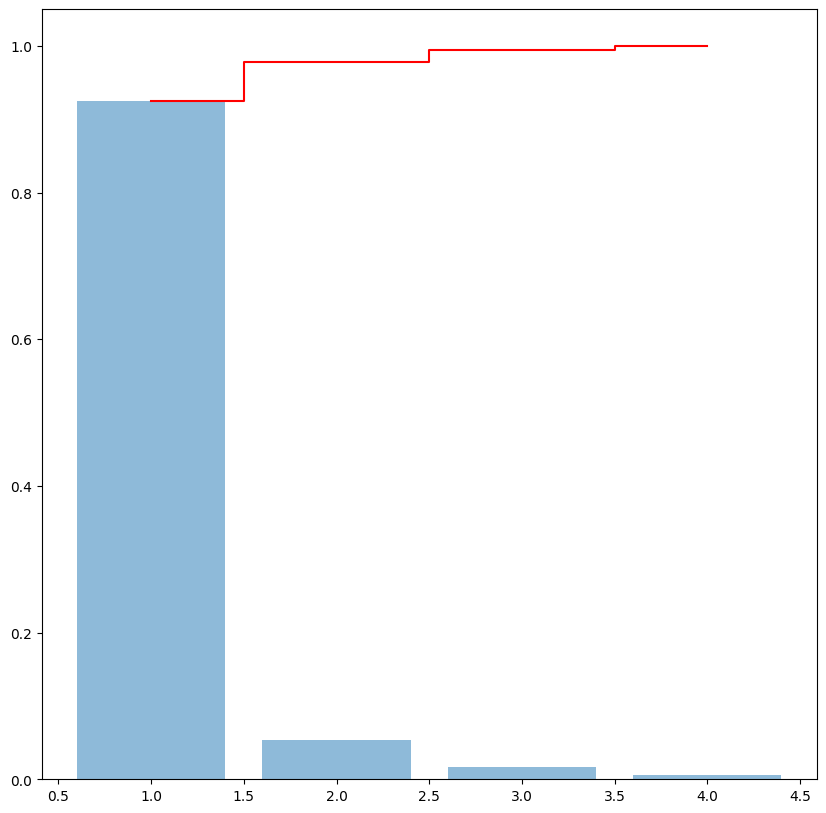

In [22]:
# 분산의 비율을 그래프로 시각화
plt.figure(figsize=(10,10))
plt.bar(
    range(1, len(explained_var_ratio) + 1),
    explained_var_ratio ,
    alpha = 0.5
)
plt.step(
    range(1, len(cum_var_ratio)+1),
    cum_var_ratio,
    color = 'red',
    where = 'mid'
)

- 막대 -> 각 주성분이 설명하는 분산의 비율
- 선 -> 누적 분산의 비율
- 일반적으로 누적 분산 비율이 90% ~ 95% 이상이 되는 지점까지의
주성분만 선택하는 경우가 다수 -> 차원 축소 근거

- 이 그래프를 보고 iris 데이터에서는 보통 두개 주성분 만으로도 데이터의 분산의 대부분인 95%을
설명이 가능하다.

In [23]:
# 독립 종속
x = iris.drop('target', axis= 1).values
y = iris['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    x,y,
    test_size= 0.2,
    random_state=42,
    stratify= y
)

# KFold를 사용하여 폴드화
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state=42)

# Pipeline 생성 -> Scaler, SVC, PCA
pipe = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('pca', PCA(random_state= 42)),
        ('svc', SVC(random_state= 42, probability= True))
    ]
)

# 최적의 파라미터를 찾기 위한 조합
params = {
    "pca__n_components" : [None, 2, 3],
    "svc__C" : [0.1, 1, 10],
    "svc__gamma" : ["scale", "auto"],
    "svc__kernel" : ['linear', 'rbf']
}  # 총 36가지의 파라미터 조합이 나온다.

# GridSearchCV 사용
grid = GridSearchCV(
    estimator= pipe,
    param_grid= params,
    scoring= "accuracy",
    cv = cv,
    n_jobs= -1,
    verbose= 1,
    refit= True,
)

# grid에 fit 함수를 사용
grid.fit(X_train, y_train)

print("Best estimator : ", grid.best_estimator_)
print("Best Parameter", grid.best_params_)
print(classification_report(y_test, grid.predict(X_test)))

# pred = grid.predict(X_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best estimator :  Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(random_state=42)),
                ('svc',
                 SVC(C=0.1, kernel='linear', probability=True,
                     random_state=42))])
Best Parameter {'pca__n_components': None, 'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'linear'}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
pd.DataFrame(grid.cv_results_).sort_values(
    "mean_test_score", ascending= False)[
        ['mean_fit_time', 'params', 'mean_test_score']
    ]